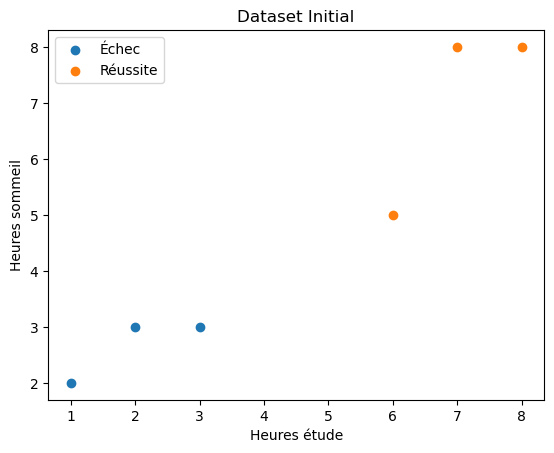

Point [2 2] ---> Échec
Point [7 7] ---> Réussite
Point [4 3] ---> Échec


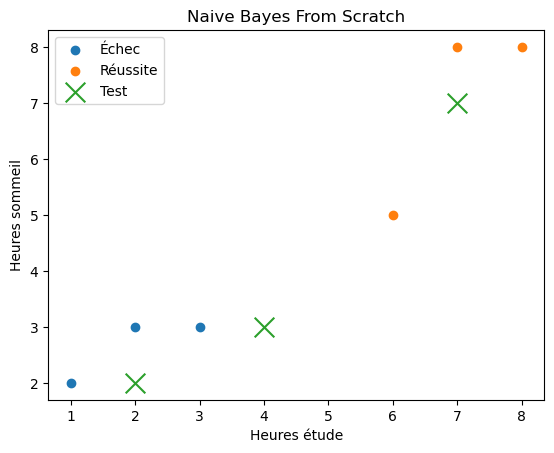

In [5]:
# ============================================================
#               NAIVE BAYES FROM SCRATCH
# ============================================================
#
#  Algorithme :
#       Gaussian Naive Bayes
#
#  Objectif :
#       Faire de la classification.
#
#  Exemple :
#       Déterminer si un étudiant va :
#
#           - Réussir
#           - Échouer
#
# ============================================================
#
#                 PRINCIPE DE BASE
# ============================================================
#
#  L’algorithme calcule :
#
#       P(Classe | Données)
#
#  puis choisit :
#
#       La plus grande probabilité.
#
# ============================================================
#
#                  THÉORÈME DE BAYES
# ============================================================
#
#                  P(X|C) * P(C)
#  P(C|X) = -------------------------
#                       P(X)
#
# ------------------------------------------------------------
#
#  P(C|X)
#       -> Probabilité que X appartienne
#          à la classe C
#
#  P(X|C)
#       -> Probabilité d’obtenir X
#          dans la classe C
#
#  P(C)
#       -> Probabilité de la classe
#
#  P(X)
#       -> Probabilité globale des données
#
# ============================================================
#
#                 HYPOTHÈSE "NAIVE"
# ============================================================
#
#  Naive Bayes suppose que :
#
#       Toutes les variables sont indépendantes.
#
#  Exemple :
#
#       Heures étude indépendant du sommeil.
#
#  Cette hypothèse est rarement vraie à 100%, mais l’algorithme fonctionne très bien.
#
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
#                    CRÉATION DU DATASET
# ============================================================
#
#  Chaque ligne représente un étudiant.
#
#  Colonne 1 :
#       Heures d'étude
#
#  Colonne 2 :
#       Heures de sommeil
#
# ============================================================

X = np.array([

    [1, 2],
    [2, 3],
    [3, 3],

    [6, 5],
    [7, 8],
    [8, 8]

])

# ============================================================
#  y représente les classes :
#
#       0 -> Échec
#       1 -> Réussite
#
#  Correspondance :
#
#       [1,2] -> Échec
#       [2,3] -> Échec
#       [3,3] -> Échec
#
#       [6,5] -> Réussite
#       [7,8] -> Réussite
#       [8,8] -> Réussite
#
# ============================================================

y = np.array([0, 0, 0, 1, 1, 1])

# ============================================================
#                  VISUALISATION DU DATASET
# ============================================================

plt.scatter(

    # Points de la classe 0
    X[y == 0][:, 0],

    # Axe Y
    X[y == 0][:, 1],

    # Nom affiché dans la légende
    label="Échec"

)

plt.scatter(

    # Points de la classe 1
    X[y == 1][:, 0],

    # Axe Y
    X[y == 1][:, 1],

    # Nom affiché dans la légende
    label="Réussite"

)

# Nom axe X

plt.xlabel("Heures étude")

# Nom axe Y

plt.ylabel("Heures sommeil")

# Titre du graphe

plt.title("Dataset Initial")

# Affichage légende

plt.legend()

# Affichage du graphique

plt.show()

# ============================================================
#                  CLASSE NAIVE BAYES
# ============================================================

class NaiveBayes:

    # ========================================================
    #                    FONCTION FIT
    # ========================================================
    #
    #  Cette fonction sert à entraîner le modèle.
    #
    #  Elle calcule :
    #
    #       1. Les classes
    #       2. Les moyennes
    #       3. Les variances
    #       4. Les probabilités des classes
    #
    # ========================================================

    def fit(self, X, y):

        # ====================================================
        # np.unique(y)
        #
        # Retourne les classes uniques.
        #
        # Exemple :
        #
        #       [0, 1]
        #
        # ====================================================

        self.classes = np.unique(y)

        # ====================================================
        # Dictionnaire des moyennes.
        #
        # Exemple :
        #
        #       mean[0]
        #       mean[1]
        #
        # ====================================================

        self.mean = {}

        # ====================================================
        # Dictionnaire des variances.
        # ====================================================

        self.var = {}

        # ====================================================
        # Dictionnaire des probabilités des classes.
        #
        # Exemple :
        #
        #       P(Échec)
        #       P(Réussite)
        #
        # ====================================================

        self.priors = {}

        # ====================================================
        # Parcours de chaque classe.
        # ====================================================

        for c in self.classes:

            # ================================================
            # Sélection uniquement des lignes
            # appartenant à la classe c.
            #
            # Exemple :
            #
            #       Si c = 0
            #
            #       On récupère uniquement
            #       les étudiants en échec.
            #
            # ================================================

            X_c = X[y == c]

            # ================================================
            #                MOYENNE
            # ================================================
            #
            # Formule :
            #
            #           x1 + x2 + ... + xn
            #   μ = -------------------------
            #                   n
            #
            # np.mean(... , axis=0)
            #
            # axis=0 :
            #       calcul colonne par colonne
            #
            # Exemple :
            #
            #       colonne étude
            #       colonne sommeil
            #
            # ================================================

            self.mean[c] = np.mean(

                X_c,

                axis=0

            )

            # ================================================
            #                VARIANCE
            # ================================================
            #
            # Formule :
            #
            #          Σ(x - μ)²
            #  σ² = ----------------
            #             n
            #
            # La variance mesure :
            #
            #       la dispersion des données
            #
            # Petite variance :
            #       données proches
            #
            # Grande variance :
            #       données dispersées
            #
            # ================================================

            self.var[c] = np.var(

                X_c,

                axis=0

            )

            # ================================================
            #          PROBABILITÉ PRIOR
            # ================================================
            #
            # Formule :
            #
            #          Nombre classe C
            #  P(C)= -------------------
            #           Nombre total
            #
            # Exemple :
            #
            #       3 réussite
            #       6 total
            #
            #       P(Réussite)=3/6=0.5
            #
            # ================================================

            self.priors[c] = (

                X_c.shape[0] / X.shape[0]

            )

    # ========================================================
    #             DISTRIBUTION GAUSSIENNE
    # ========================================================
    #
    #  Cette fonction calcule :
    #
    #       P(X|C)
    #
    #  en utilisant la loi normale.
    #
    # ========================================================

    def gaussian(self, class_idx, x):

        # ====================================================
        # Récupération de la moyenne
        # correspondant à la classe.
        # ====================================================

        mean = self.mean[class_idx]

        # ====================================================
        # Récupération de la variance
        # correspondant à la classe.
        # ====================================================

        var = self.var[class_idx]

        # ====================================================
        # Petite valeur ajoutée pour éviter :
        #
        #       division par zéro
        #
        # ====================================================

        epsilon = 1e-4

        # ====================================================
        #              FORMULE GAUSSIENNE
        # ====================================================
        #
        #                -(x-μ)²
        #               --------
        #                  2σ²
        #             e
        #  P(x)= ---------------------
        #             √(2πσ²)
        #
        # ====================================================

        # ====================================================
        # Partie exponentielle :
        #
        #              -(x-μ)²
        #              --------
        #                2σ²
        #            e
        #
        # np.exp() calcule :
        #
        #       e^x
        #
        # ====================================================

        numerator = np.exp(

            -(x - mean) ** 2 /

            (2 * var + epsilon)

        )

        # ====================================================
        # Partie dénominateur :
        #
        #       √(2πσ²)
        #
        # np.sqrt()
        #
        #       calcule la racine carrée
        #
        # ====================================================

        denominator = np.sqrt(

            2 * np.pi * var + epsilon

        )

        # ====================================================
        # Retour de la densité de probabilité.
        # ====================================================

        return numerator / denominator

    # ========================================================
    #           PRÉDICTION D’UN SEUL POINT
    # ========================================================

    def predict_sample(self, x):

        # ====================================================
        # Liste qui va stocker :
        #
        #       les probabilités finales
        #
        # ====================================================

        posteriors = []

        # ====================================================
        # Parcours des classes.
        # ====================================================

        for c in self.classes:

            # ================================================
            #                PRIOR
            # ================================================
            #
            # prior = log(P(C))
            #
            # np.log utilisé pour éviter :
            #
            #       les très petites valeurs
            #
            # ================================================

            prior = np.log(

                self.priors[c]

            )

            # ================================================
            #               LIKELIHOOD
            # ================================================
            #
            # Formule :
            #
            # P(X|C)=P(x1|C)*P(x2|C)*...*P(xn|C)
            #
            # Produit des probabilités
            # des variables.
            #
            # Comme les produits deviennent
            # très petits :
            #
            # on utilise log.
            #
            # log(a*b*c)=log(a)+log(b)+log(c)
            #
            # ================================================

            likelihood = np.sum(

                np.log(

                    self.gaussian(c, x)

                )

            )

            # ================================================
            #               POSTERIOR
            # ================================================
            #
            # posterior = prior + likelihood
            #
            # C’est la probabilité finale.
            #
            # ================================================

            posterior = prior + likelihood

            # ================================================
            # Ajout dans la liste.
            # ================================================

            posteriors.append(

                posterior

            )

        # ====================================================
        # np.argmax(posteriors)
        #
        # Retourne l’indice de la plus grande valeur.
        #
        # Exemple :
        #
        #       [ -10 , -2 ]
        #
        #       max = -2
        #
        #       indice = 1
        #
        # Donc :
        #
        #       classe 1
        #
        # ====================================================

        return self.classes[

            np.argmax(posteriors)

        ]

    # ========================================================
    #           PRÉDICTION DE PLUSIEURS POINTS
    # ========================================================

    def predict(self, X):

        # ====================================================
        # Liste des prédictions.
        # ====================================================

        predictions = []

        # ====================================================
        # Parcours des données test.
        # ====================================================

        for x in X:

            # ================================================
            # Prédiction d’un seul point.
            # ================================================

            predictions.append(

                self.predict_sample(x)

            )

        # ====================================================
        # Conversion en tableau numpy.
        # ====================================================

        return np.array(predictions)

# ============================================================
#                CRÉATION DU MODÈLE
# ============================================================

model = NaiveBayes()

# ============================================================
#                  ENTRAÎNEMENT
# ============================================================
#
# Le modèle apprend :
#
#       - moyennes
#       - variances
#       - probabilités
#
# ============================================================

model.fit(X, y)

# ============================================================
#                  DONNÉES TEST
# ============================================================
#
# Nouveaux étudiants à classifier.
#
# ============================================================

X_test = np.array([

    [2, 2],
    [7, 7],
    [4, 3]

])

# ============================================================
#                    PRÉDICTIONS
# ============================================================

predictions = model.predict(X_test)

# ============================================================
#               AFFICHAGE DES RÉSULTATS
# ============================================================

for i, pred in enumerate(predictions):

    # ========================================================
    # Si la classe prédite = 0
    # ========================================================

    if pred == 0:

        result = "Échec"

    # ========================================================
    # Sinon :
    # ========================================================

    else:

        result = "Réussite"

    # ========================================================
    # Affichage du résultat final.
    # ========================================================

    print(

        f"Point {X_test[i]} ---> {result}"

    )

# ============================================================
#               VISUALISATION FINALE
# ============================================================

plt.scatter(

    # Étudiants en échec
    X[y == 0][:, 0],

    X[y == 0][:, 1],

    label="Échec"

)

plt.scatter(

    # Étudiants réussite
    X[y == 1][:, 0],

    X[y == 1][:, 1],

    label="Réussite"

)

plt.scatter(

    # Points test
    X_test[:, 0],

    X_test[:, 1],

    marker='x',

    s=200,

    label="Test"

)

# ============================================================
#                  TITRE ET AXES
# ============================================================

plt.title(

    "Naive Bayes From Scratch"

)

plt.xlabel(

    "Heures étude"

)

plt.ylabel(

    "Heures sommeil"

)

# Affichage légende

plt.legend()

# Affichage graphique

plt.show()